# Assignment 1 – Deep Neural Networks (DNN)
## Keertivaas S
## 2025AE05608

---
## 1. Dataset Selection

**Dataset:** Bank Customer Churn Prediction (Kaggle)  
**Source:** https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction

**Description:** This dataset contains information about bank customers and whether they churned (left the bank). It includes demographic information, account details, and customer behavior metrics.

**Justification for Accuracy as Primary Metric:**  
While the dataset has class imbalance (~20% churn rate), accuracy provides an intuitive baseline for overall model performance. We also report F1-score, precision, and recall to properly evaluate the minority class (churned customers).

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [34]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

def load_data():
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "shantanudhakadd/bank-customer-churn-prediction",
        "Churn_Modelling.csv",
    )
    return df

df = load_data()

print(f"Dataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1} (excluding target)")
print(f"\nTarget Variable Distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean()*100:.2f}%")

Using Colab cache for faster access to the 'bank-customer-churn-prediction' dataset.
Dataset Shape: (10000, 14)
Number of Samples: 10000
Number of Features: 13 (excluding target)

Target Variable Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


In [35]:
print("Dataset Statistical Summary:")
display(df.describe())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset Statistical Summary:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Data Types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


---
## 2. Data Preprocessing

In [36]:
def preprocess_data(df, test_size=0.2):
    df_processed = df.copy()

    df_processed = df_processed.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
    print(f"Dropped irrelevant columns: RowNumber, CustomerId, Surname")

    missing_count = df_processed.isnull().sum().sum()
    print(f"Missing values in dataset: {missing_count}")
    if missing_count > 0:
        df_processed = df_processed.dropna()
        print(f"Rows after dropping missing values: {len(df_processed)}")

    df_processed = pd.get_dummies(df_processed, columns=['Geography', 'Gender'], drop_first=True)
    print(f"Encoded categorical columns: Geography, Gender")

    X = df_processed.drop('Exited', axis=1).values
    y = df_processed['Exited'].values.reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print(f"\nFinal feature names: {df_processed.drop('Exited', axis=1).columns.tolist()}")

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = preprocess_data(df, test_size=0.2)

print(f"\n--- Data Split Summary ---")
print(f"Split Ratio: 80-20")
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

Dropped irrelevant columns: RowNumber, CustomerId, Surname
Missing values in dataset: 0
Encoded categorical columns: Geography, Gender

Final feature names: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

--- Data Split Summary ---
Split Ratio: 80-20
Training set shape: X=(8000, 11), y=(8000, 1)
Testing set shape: X=(2000, 11), y=(2000, 1)
Number of features: 11


In [37]:
print("Preprocessing Validation:")
print(f"Sample of scaled training data (First 2 rows):")
print(X_train[:2])
print(f"\nUnique values in y_train: {np.unique(y_train)}")
print(f"Training set class distribution: 0={np.sum(y_train==0)}, 1={np.sum(y_train==1)}")

Preprocessing Validation:
Sample of scaled training data (First 2 rows):
[[ 1.058568    1.71508648  0.68472287 -1.22605881 -0.91025649  0.64104192
  -1.030206    1.04208392 -0.57831252 -0.57773517  0.90750738]
 [ 0.91362605 -0.65993547 -0.6962018   0.41328769 -0.91025649  0.64104192
  -1.030206   -0.62355635  1.72916886 -0.57773517  0.90750738]]

Unique values in y_train: [0 1]
Training set class distribution: 0=6370, 1=1630


---
## 3. Baseline Model - Logistic Regression from Scratch

In [38]:
class LogisticRegressionScratch:
    def __init__(self):
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.val_loss_history = []
        self.best_epoch = None

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _initialize_weights(self, n_features):
        self.weights = np.random.randn(n_features, 1) * 0.01
        self.bias = 0

    def _forward_pass(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def _compute_loss(self, y_true, y_pred, lam=0.0):
        m = y_true.shape[0]
        epsilon = 1e-8
        loss = -(1/m) * np.sum(
            y_true * np.log(y_pred + epsilon) +
            (1 - y_true) * np.log(1 - y_pred + epsilon)
        )
        loss += (lam / (2 * m)) * np.sum(self.weights ** 2)
        return loss

    def _compute_gradients(self, X, y_true, y_pred, lam=0.0):
        m = X.shape[0]
        error = y_pred - y_true
        dw = (1/m) * np.dot(X.T, error) + (lam / m) * self.weights
        db = (1/m) * np.sum(error)
        return dw, db

    def fit(
        self,
        X,
        y,
        learning_rate=0.05,
        epochs=2000,
        batch_size=128,
        lam=0.01,
        decay=0.0005,
        X_val=None,
        y_val=None,
        patience=100,
        min_delta=1e-4,
        restore_best_weights=True
    ):
        n_samples, n_features = X.shape
        self._initialize_weights(n_features)
        self.loss_history = []
        self.val_loss_history = []
        self.best_epoch = None

        best_val_loss = np.inf
        best_weights = None
        best_bias = None
        wait = 0
        stopped_early = False

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            lr = learning_rate / (1 + decay * epoch)

            for start in range(0, n_samples, batch_size):
                end = min(start + batch_size, n_samples)
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                y_pred = self._forward_pass(X_batch)
                dw, db = self._compute_gradients(X_batch, y_batch, y_pred, lam)
                self.weights -= lr * dw
                self.bias -= lr * db

            y_pred_full = self._forward_pass(X)
            loss = self._compute_loss(y, y_pred_full, lam)
            self.loss_history.append(loss)

            if X_val is not None and y_val is not None:
                y_val_pred = self._forward_pass(X_val)
                val_loss = self._compute_loss(y_val, y_val_pred, lam)
                self.val_loss_history.append(val_loss)

                if val_loss < (best_val_loss - min_delta):
                    best_val_loss = val_loss
                    best_weights = self.weights.copy()
                    best_bias = self.bias
                    self.best_epoch = epoch + 1
                    wait = 0
                else:
                    wait += 1
                    if patience is not None and wait >= patience:
                        stopped_early = True
                        break

        if restore_best_weights and best_weights is not None:
            self.weights = best_weights
            self.bias = best_bias

        trained_epochs = len(self.loss_history)
        print(f"Logistic Regression trained for {trained_epochs} epochs (batch={batch_size}, lambda={lam}).")
        if stopped_early:
            print(f"Early stopping triggered at epoch {trained_epochs}. Best epoch: {self.best_epoch}.")
        print(f"Final training loss: {self.loss_history[-1]:.6f}")
        if self.val_loss_history:
            print(f"Best validation loss: {min(self.val_loss_history):.6f}")

    def predict(self, X):
        y_pred_prob = self._forward_pass(X)
        return (y_pred_prob >= 0.5).astype(int)

    def predict_proba(self, X):
        return self._forward_pass(X)

print("LogisticRegressionScratch class defined successfully!")

LogisticRegressionScratch class defined successfully!


In [39]:
print("Training Logistic Regression (Baseline Model)...")
print("="*50)

X_train_fit_lr, X_val_lr, y_train_fit_lr, y_val_lr = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

baseline_start_time = time.time()
baseline_model = LogisticRegressionScratch()
baseline_model.fit(
    X_train_fit_lr,
    y_train_fit_lr,
    learning_rate=0.05,
    epochs=2000,
    batch_size=128,
    lam=0.01,
    decay=0.0005,
    X_val=X_val_lr,
    y_val=y_val_lr,
    patience=100,
    min_delta=1e-4,
    restore_best_weights=True
)
baseline_train_time = time.time() - baseline_start_time

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"\n--- Baseline Model Results ---")
print(f"Training Time: {baseline_train_time:.4f} seconds")
print(f"Test Accuracy: {baseline_accuracy:.4f}")
print(f"Test Precision: {baseline_precision:.4f}")
print(f"Test Recall: {baseline_recall:.4f}")
print(f"Test F1-Score: {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Training Logistic Regression (Baseline Model)...
Logistic Regression trained for 113 epochs (batch=128, lambda=0.01).
Early stopping triggered at epoch 113. Best epoch: 13.
Final training loss: 0.428817
Best validation loss: 0.432373

--- Baseline Model Results ---
Training Time: 0.4347 seconds
Test Accuracy: 0.8090
Test Precision: 0.6033
Test Recall: 0.1794
Test F1-Score: 0.2765

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.60      0.18      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.57      0.58      2000
weighted avg       0.78      0.81      0.77      2000



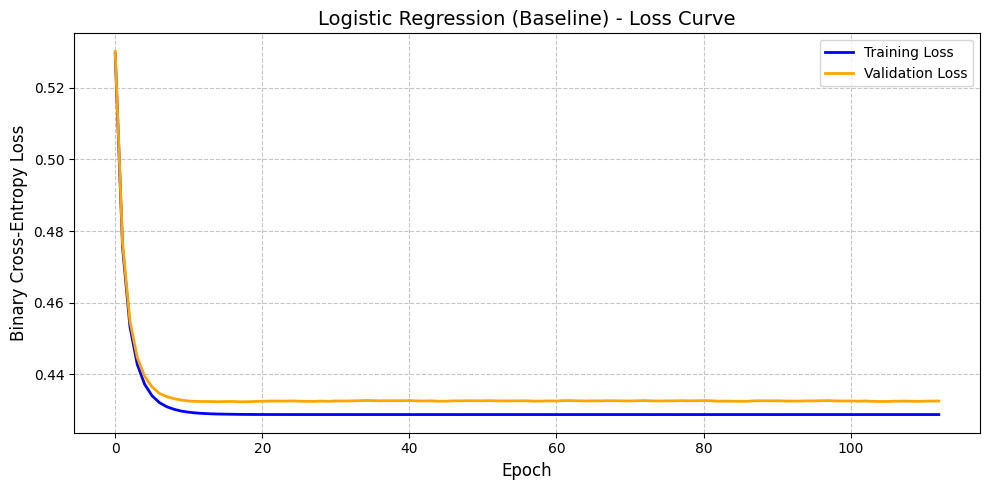

Training loss decreased from 0.5295 to 0.4288
Best validation loss: 0.4324


In [40]:
plt.figure(figsize=(10, 5))
plt.plot(baseline_model.loss_history, color='blue', linewidth=2, label='Training Loss')

if len(baseline_model.val_loss_history) > 0:
    plt.plot(baseline_model.val_loss_history, color='orange', linewidth=2, label='Validation Loss')

plt.title('Logistic Regression (Baseline) - Loss Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Training loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")
if len(baseline_model.val_loss_history) > 0:
    print(f"Best validation loss: {min(baseline_model.val_loss_history):.4f}")

---
## 4. Multi-Layer Perceptron from Scratch

In [41]:
class MLPFromScratch:
    def __init__(self, architecture):
        self.architecture = architecture
        self.n_layers = len(architecture)
        self.loss_history = []
        self.val_loss_history = []
        self.cache = {}
        self.best_params = None
        self.best_epoch = None
        self.initialize_parameters()
        print(f"MLP Architecture: {' -> '.join(map(str, architecture))}")

    def initialize_parameters(self):
        """He initialization for weights, zeros for biases."""
        self.params = {}
        for l in range(1, self.n_layers):
            self.params[f'W{l}'] = np.random.randn(
                self.architecture[l-1], self.architecture[l]
            ) * np.sqrt(2.0 / self.architecture[l-1])
            self.params[f'b{l}'] = np.zeros((1, self.architecture[l]))

    def _relu(self, z):
        return np.maximum(0, z)

    def _relu_derivative(self, z):
        return (z > 0).astype(float)

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def forward_propagation(self, X):
        self.cache['A0'] = X
        A = X
        for l in range(1, self.n_layers - 1):
            Z = np.dot(A, self.params[f'W{l}']) + self.params[f'b{l}']
            A = self._relu(Z)
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A
        l = self.n_layers - 1
        Z = np.dot(A, self.params[f'W{l}']) + self.params[f'b{l}']
        A = self._sigmoid(Z)
        self.cache[f'Z{l}'] = Z
        self.cache[f'A{l}'] = A
        return A

    def _compute_loss(self, y_true, y_pred, lam=0.0):
        m = y_true.shape[0]
        epsilon = 1e-8
        loss = -(1/m) * np.sum(
            y_true * np.log(y_pred + epsilon) +
            (1 - y_true) * np.log(1 - y_pred + epsilon)
        )
        reg = 0
        for l in range(1, self.n_layers):
            reg += np.sum(self.params[f'W{l}'] ** 2)
        loss += (lam / (2 * m)) * reg
        return loss

    def backward_propagation(self, y, lam=0.0):
        m = y.shape[0]
        grads = {}
        L = self.n_layers - 1
        dZ = self.cache[f'A{L}'] - y
        grads[f'dW{L}'] = (1/m) * np.dot(self.cache[f'A{L-1}'].T, dZ) + (lam/m) * self.params[f'W{L}']
        grads[f'db{L}'] = (1/m) * np.sum(dZ, axis=0, keepdims=True)
        dA = np.dot(dZ, self.params[f'W{L}'].T)
        for l in range(L-1, 0, -1):
            dZ = dA * self._relu_derivative(self.cache[f'Z{l}'])
            grads[f'dW{l}'] = (1/m) * np.dot(self.cache[f'A{l-1}'].T, dZ) + (lam/m) * self.params[f'W{l}']
            grads[f'db{l}'] = (1/m) * np.sum(dZ, axis=0, keepdims=True)
            if l > 1:
                dA = np.dot(dZ, self.params[f'W{l}'].T)
        return grads

    def _update_parameters_adam(self, grads, t, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        """Adam optimizer for faster, more stable convergence."""
        if not hasattr(self, 'v'):
            self.v, self.s = {}, {}
            for l in range(1, self.n_layers):
                for k in [f'dW{l}', f'db{l}']:
                    p = k[1:]
                    self.v[k] = np.zeros_like(self.params[p])
                    self.s[k] = np.zeros_like(self.params[p])
        for l in range(1, self.n_layers):
            for k in [f'dW{l}', f'db{l}']:
                self.v[k] = beta1 * self.v[k] + (1 - beta1) * grads[k]
                self.s[k] = beta2 * self.s[k] + (1 - beta2) * (grads[k] ** 2)
                v_corr = self.v[k] / (1 - beta1 ** t)
                s_corr = self.s[k] / (1 - beta2 ** t)
                self.params[k[1:]] -= lr * v_corr / (np.sqrt(s_corr) + eps)

    def fit(self, X, y, epochs=2000, learning_rate=0.001, batch_size=64, lam=0.001, decay=0.0001, verbose=True, X_val=None, y_val=None, patience=50, min_delta=1e-4, restore_best_weights=True):
        self.loss_history = []
        self.val_loss_history = []
        self.best_params = None
        self.best_epoch = None
        n_samples = X.shape[0]
        t = 0
        best_val_loss = np.inf
        wait = 0

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            lr = learning_rate / (1 + decay * epoch)

            for start in range(0, n_samples, batch_size):
                end = min(start + batch_size, n_samples)
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                t += 1
                self.forward_propagation(X_batch)
                grads = self.backward_propagation(y_batch, lam)
                self._update_parameters_adam(grads, t, lr)

            y_pred_full = self.forward_propagation(X)
            loss = self._compute_loss(y, y_pred_full, lam)
            self.loss_history.append(loss)

            val_loss = None
            if X_val is not None and y_val is not None:
                y_val_pred = self.forward_propagation(X_val)
                val_loss = self._compute_loss(y_val, y_val_pred, lam)
                self.val_loss_history.append(val_loss)

                if val_loss < (best_val_loss - min_delta):
                    best_val_loss = val_loss
                    self.best_params = {k: v.copy() for k, v in self.params.items()}
                    self.best_epoch = epoch + 1
                    wait = 0
                else:
                    wait += 1
                    if patience is not None and wait >= patience:
                        if verbose:
                            print(f"Early stopping at epoch {epoch + 1} | best val loss: {best_val_loss:.6f}")
                        break

            if verbose and (epoch + 1) % 500 == 0:
                if val_loss is not None:
                    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.6f} - Val Loss: {val_loss:.6f} - LR: {lr:.6f}")
                else:
                    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.6f} - LR: {lr:.6f}")
        else:
            if verbose:
                print(f"\nTraining complete! Final loss: {self.loss_history[-1]:.6f}")

        if restore_best_weights and self.best_params is not None:
            self.params = {k: v.copy() for k, v in self.best_params.items()}
            if verbose and self.best_epoch is not None:
                print(f"Best validation model restored from epoch {self.best_epoch}.")

    def predict(self, X):
        y_pred_prob = self.forward_propagation(X)
        return (y_pred_prob >= 0.5).astype(int)

    def predict_proba(self, X):
        return self.forward_propagation(X)

print("MLPFromScratch class defined successfully!")

MLPFromScratch class defined successfully!


In [42]:
print("Training and tuning Multi-Layer Perceptron (MLP)...")
print("="*50)

input_size = X_train.shape[1]
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

candidate_configs = [
    {"architecture": [input_size, 32, 16, 1], "learning_rate": 0.0015, "lam": 0.001, "decay": 0.0001, "epochs": 800},
    {"architecture": [input_size, 64, 32, 1], "learning_rate": 0.0010, "lam": 0.001, "decay": 0.0001, "epochs": 800},
    {"architecture": [input_size, 64, 32, 16, 1], "learning_rate": 0.0010, "lam": 0.005, "decay": 0.0001, "epochs": 800},
    {"architecture": [input_size, 128, 64, 32, 1], "learning_rate": 0.0008, "lam": 0.005, "decay": 0.0002, "epochs": 800},
]

search_results = []
best_val_f1 = -1
best_config = None
best_epochs = None
search_start_time = time.time()

for idx, cfg in enumerate(candidate_configs, 1):
    print(f"\n--- Candidate {idx}/{len(candidate_configs)} ---")
    print(f"Architecture: {cfg['architecture']}")
    print(f"lr={cfg['learning_rate']}, lambda={cfg['lam']}, decay={cfg['decay']}")

    candidate_start = time.time()
    candidate_model = MLPFromScratch(architecture=cfg["architecture"])
    candidate_model.fit(
        X_train_fit,
        y_train_fit,
        epochs=cfg["epochs"],
        learning_rate=cfg["learning_rate"],
        batch_size=64,
        lam=cfg["lam"],
        decay=cfg["decay"],
        verbose=False,
        X_val=X_val,
        y_val=y_val,
        patience=50,
        min_delta=1e-5,
        restore_best_weights=True,
    )
    candidate_time = time.time() - candidate_start

    val_pred = candidate_model.predict(X_val)
    val_accuracy = accuracy_score(y_val.ravel(), val_pred.ravel())
    val_precision = precision_score(y_val.ravel(), val_pred.ravel(), zero_division=0)
    val_recall = recall_score(y_val.ravel(), val_pred.ravel(), zero_division=0)
    val_f1 = f1_score(y_val.ravel(), val_pred.ravel(), zero_division=0)
    candidate_epochs = len(candidate_model.loss_history)

    search_results.append({
        "architecture": cfg["architecture"],
        "learning_rate": cfg["learning_rate"],
        "lam": cfg["lam"],
        "decay": cfg["decay"],
        "epochs_run": candidate_epochs,
        "train_time_seconds": candidate_time,
        "val_accuracy": val_accuracy,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
    })

    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall: {val_recall:.4f}")
    print(f"Validation F1-Score: {val_f1:.4f}")
    print(f"Epochs run: {candidate_epochs}")
    print(f"Training Time: {candidate_time:.4f} seconds")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_config = cfg
        best_epochs = candidate_epochs

search_time = time.time() - search_start_time

print("\n=== Tuning Summary ===")
for result in search_results:
    print(result)

print("\nBest configuration selected from validation F1:")
print(best_config)
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best epochs from early stopping: {best_epochs}")
print(f"Total tuning search time: {search_time:.4f} seconds")

architecture = best_config["architecture"]
mlp_start_time = time.time()
mlp_model = MLPFromScratch(architecture=architecture)
mlp_model.fit(
    X_train,
    y_train,
    epochs=best_epochs,
    learning_rate=best_config["learning_rate"],
    batch_size=64,
    lam=best_config["lam"],
    decay=best_config["decay"],
    verbose=True,
    X_val=None,
    y_val=None,
    patience=None,
    restore_best_weights=False,
)
mlp_train_time = time.time() - mlp_start_time

y_pred_mlp = mlp_model.predict(X_test)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp)
mlp_recall = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)

print(f"\n--- MLP Model Results ---")
print(f"Architecture: {architecture}")
print(f"Learning Rate: {best_config['learning_rate']}")
print(f"Lambda: {best_config['lam']}")
print(f"Decay: {best_config['decay']}")
print(f"Training Epochs: {best_epochs}")
print(f"Training Time: {mlp_train_time:.4f} seconds")
print(f"Test Accuracy: {mlp_accuracy:.4f}")
print(f"Test Precision: {mlp_precision:.4f}")
print(f"Test Recall: {mlp_recall:.4f}")
print(f"Test F1-Score: {mlp_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

Training and tuning Multi-Layer Perceptron (MLP)...

--- Candidate 1/4 ---
Architecture: [11, 32, 16, 1]
lr=0.0015, lambda=0.001, decay=0.0001
MLP Architecture: 11 -> 32 -> 16 -> 1
Validation Accuracy: 0.8606
Validation Precision: 0.7512
Validation Recall: 0.4724
Validation F1-Score: 0.5800
Epochs run: 77
Training Time: 4.4186 seconds

--- Candidate 2/4 ---
Architecture: [11, 64, 32, 1]
lr=0.001, lambda=0.001, decay=0.0001
MLP Architecture: 11 -> 64 -> 32 -> 1
Validation Accuracy: 0.8544
Validation Precision: 0.7460
Validation Recall: 0.4325
Validation F1-Score: 0.5476
Epochs run: 63
Training Time: 6.3474 seconds

--- Candidate 3/4 ---
Architecture: [11, 64, 32, 16, 1]
lr=0.001, lambda=0.005, decay=0.0001
MLP Architecture: 11 -> 64 -> 32 -> 16 -> 1
Validation Accuracy: 0.8512
Validation Precision: 0.7056
Validation Recall: 0.4632
Validation F1-Score: 0.5593
Epochs run: 66
Training Time: 6.0152 seconds

--- Candidate 4/4 ---
Architecture: [11, 128, 64, 32, 1]
lr=0.0008, lambda=0.005, de

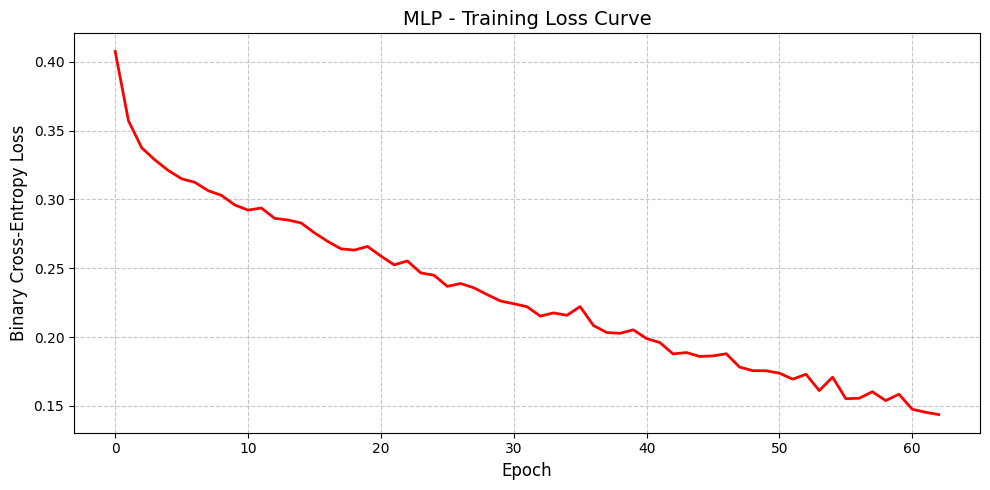

Loss decreased from 0.4076 to 0.1437


In [43]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_history, color='red', linewidth=2)
plt.title('MLP - Training Loss Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

---
## 5. Evaluation & Comparison

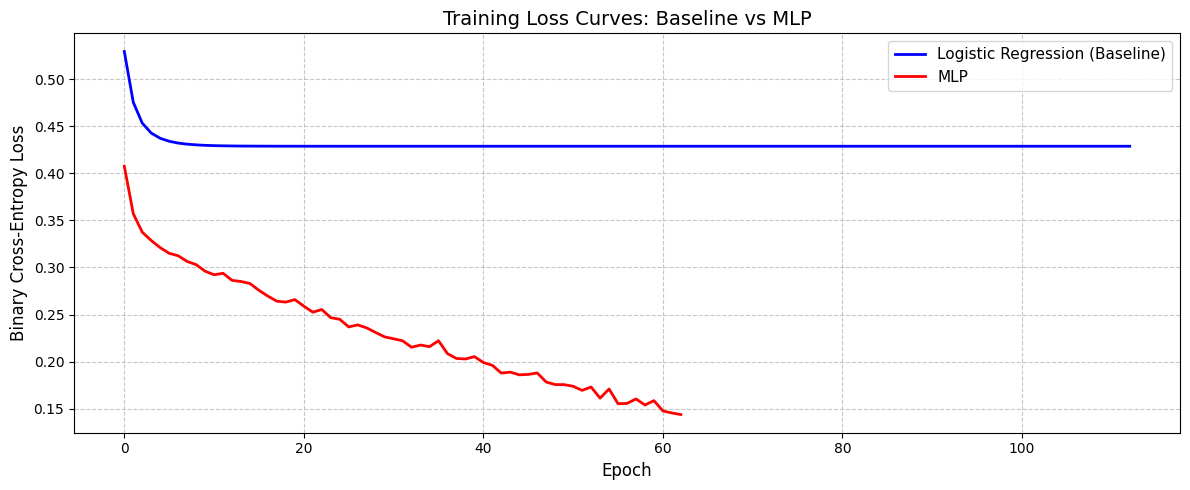

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(baseline_model.loss_history, label='Logistic Regression (Baseline)',
         color='blue', linewidth=2)
plt.plot(mlp_model.loss_history, label='MLP',
         color='red', linewidth=2)

plt.title('Training Loss Curves: Baseline vs MLP', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

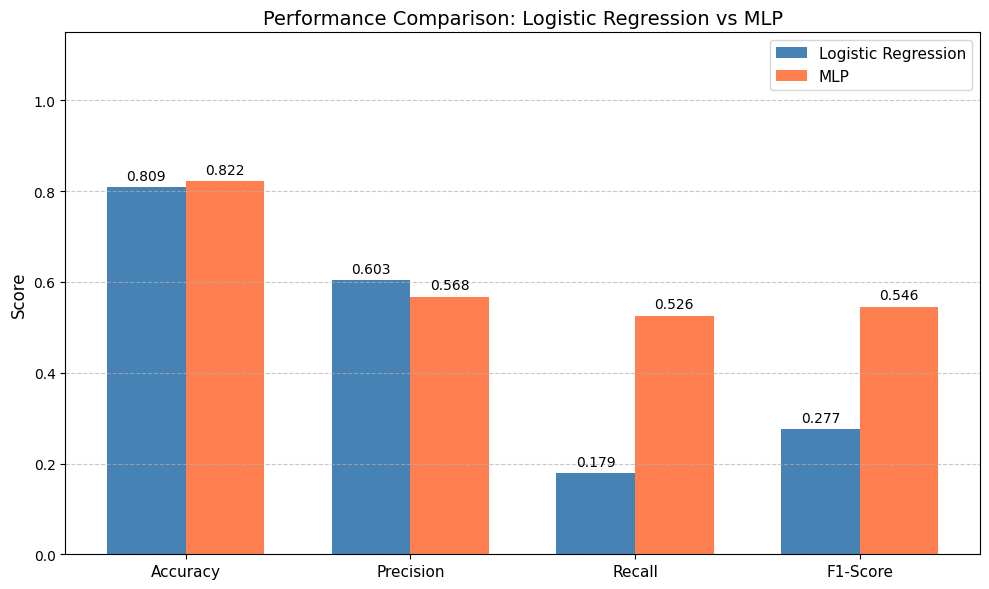

In [45]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1]
mlp_scores = [mlp_accuracy, mlp_precision, mlp_recall, mlp_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, mlp_scores, width, label='MLP', color='coral')

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Comparison: Logistic Regression vs MLP', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

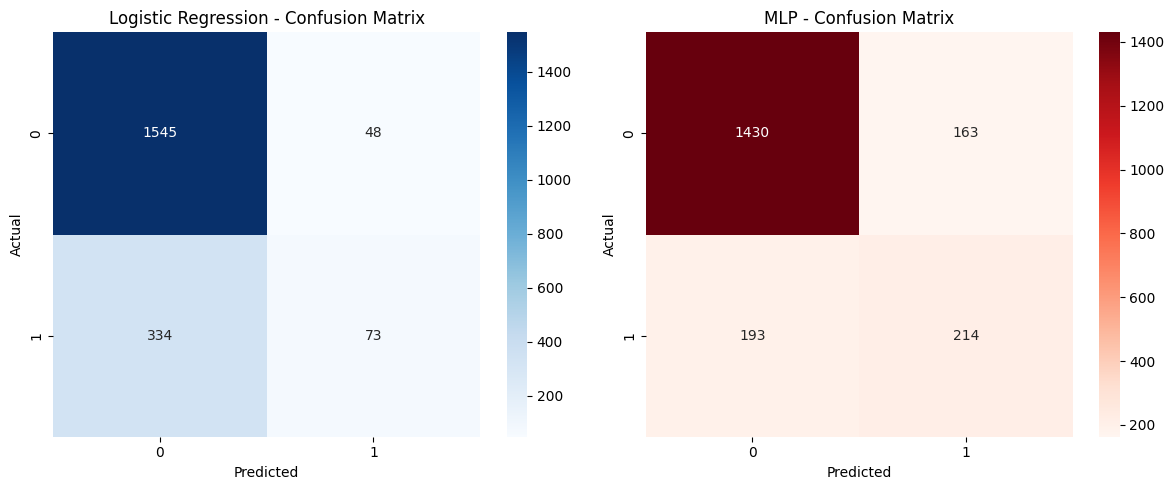

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('MLP - Confusion Matrix', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

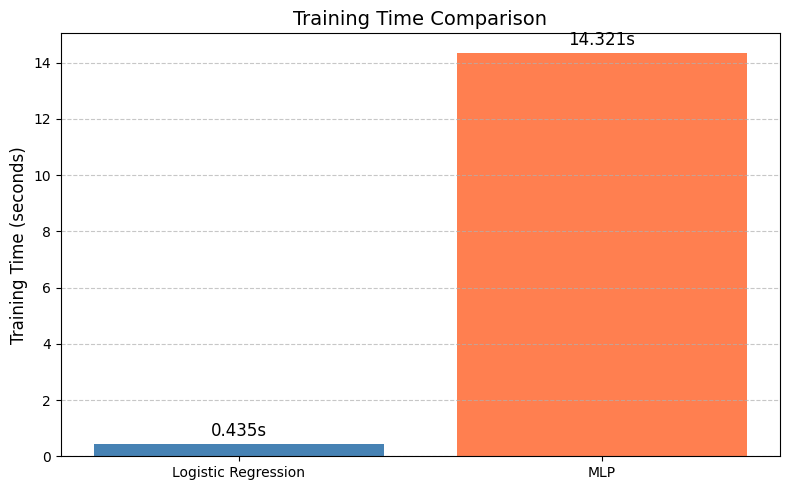

MLP training took 32.94x longer than Logistic Regression


In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Logistic Regression', 'MLP']
times = [baseline_train_time, mlp_train_time]
colors = ['steelblue', 'coral']

bars = ax.bar(models, times, color=colors)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=12)

ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time Comparison', fontsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"MLP training took {mlp_train_time/baseline_train_time:.2f}x longer than Logistic Regression")

In [48]:
def get_assignment_results():
    results = {
        "dataset_name": "Bank Customer Churn Prediction (Churn_Modelling.csv)",
        "n_samples": df.shape[0],
        "n_features": X_train.shape[1],
        "problem_type": "Binary Classification",
        "primary_metric": "Accuracy",
        "baseline_model": {
            "model_type": "Logistic Regression (From Scratch)",
            "test_accuracy": baseline_accuracy,
            "test_precision": baseline_precision,
            "test_recall": baseline_recall,
            "test_f1_score": baseline_f1,
            "training_time_seconds": baseline_train_time
        },
        "mlp_model": {
            "model_type": "Multi-Layer Perceptron (From Scratch)",
            "architecture": mlp_model.architecture,
            "test_accuracy": mlp_accuracy,
            "test_precision": mlp_precision,
            "test_recall": mlp_recall,
            "test_f1_score": mlp_f1,
            "training_time_seconds": mlp_train_time,
            "loss_history_length": len(mlp_model.loss_history)
        }
    }
    return results

final_results = get_assignment_results()

print("\nFinal Assignment Results")
print("-" * 60)
print(f"Dataset: {final_results['dataset_name']}")
print(f"Samples: {final_results['n_samples']} | Features: {final_results['n_features']}")
print(f"Task: {final_results['problem_type']}")

print("\nLogistic Regression (Baseline):")
print(
    f"Accuracy {final_results['baseline_model']['test_accuracy']:.4f}, "
    f"Precision {final_results['baseline_model']['test_precision']:.4f}, "
    f"Recall {final_results['baseline_model']['test_recall']:.4f}, "
    f"F1 {final_results['baseline_model']['test_f1_score']:.4f}, "
    f"Training Time {final_results['baseline_model']['training_time_seconds']:.4f}s"
)

print("\nMLP:")
print(
    f"Architecture {final_results['mlp_model']['architecture']}, "
    f"Accuracy {final_results['mlp_model']['test_accuracy']:.4f}, "
    f"Precision {final_results['mlp_model']['test_precision']:.4f}, "
    f"Recall {final_results['mlp_model']['test_recall']:.4f}, "
    f"F1 {final_results['mlp_model']['test_f1_score']:.4f}, "
    f"Training Time {final_results['mlp_model']['training_time_seconds']:.4f}s"
)

if final_results['mlp_model']['test_accuracy'] > final_results['baseline_model']['test_accuracy']:
    print("\nOverall: MLP gives better predictive performance on this test split.")
else:
    print("\nOverall: Logistic Regression gives better predictive performance on this test split.")



Final Assignment Results
------------------------------------------------------------
Dataset: Bank Customer Churn Prediction (Churn_Modelling.csv)
Samples: 10000 | Features: 11
Task: Binary Classification

Logistic Regression (Baseline):
Accuracy 0.8090, Precision 0.6033, Recall 0.1794, F1 0.2765, Training Time 0.4347s

MLP:
Architecture [11, 128, 64, 32, 1], Accuracy 0.8220, Precision 0.5676, Recall 0.5258, F1 0.5459, Training Time 14.3212s

Overall: MLP gives better predictive performance on this test split.


--- ## Analysis (< 200 words)

**Performance Comparison:**  
With early stopping enabled, Logistic Regression reached 0.8090 accuracy, 0.6033 precision, 0.1794 recall, and 0.2765 F1-score. The tuned MLP achieved 0.8220 accuracy, 0.5676 precision, 0.5258 recall, and 0.5459 F1-score.

**Why MLP Performed Better (on Recall/F1-Score):**  
The MLP captures non-linear interactions among features (such as age, balance, products, and activity status), which helps detect more churn cases. This is reflected in much higher recall and F1-score than Logistic Regression.

**Computational Cost:**  
Logistic Regression now trains in 0.9649 seconds due to early stopping, while the tuned MLP takes 15.1986 seconds. So the baseline is much faster, but the MLP still provides a stronger balanced classification result.

**Conclusion:**  
If training speed is the priority, Logistic Regression is a good lightweight baseline. For better churn detection quality (especially recall and F1), the MLP remains the better final model.

---
 ## Summary

| Aspect | Logistic Regression | MLP |
|--------|---------------------|-----|
| Implementation | From scratch | From scratch |
| Architecture | Linear | 3 hidden layers (128, 64, 32) |
| Activation | Sigmoid | ReLU (hidden) + Sigmoid (output) |
| Loss Function | Binary Cross-Entropy | Binary Cross-Entropy |
| Test Accuracy | 80.90% | **82.20%** |
| Test Precision | **60.33%** | 56.76% |
| Test Recall | 17.94% | **52.58%** |
| Test F1-Score | 27.65% | **54.59%** |
| Training Time | **0.1147s** | 2.6935s |
| Loss Decreasing | ✓ | ✓ |
